# Fetching and Exploring the MNIST Dataset

In [2]:
# Downloading the mnist dataset
from sklearn.datasets import fetch_openml
mnist =  fetch_openml('mnist_784', version=1, as_frame=False)
# mnist

In [5]:
# Examining the arrays
X, y = mnist["data"], mnist["target"]
X.shape

(70000, 784)

In [6]:
y.shape

(70000,)

# Examining the MNIST Dataset

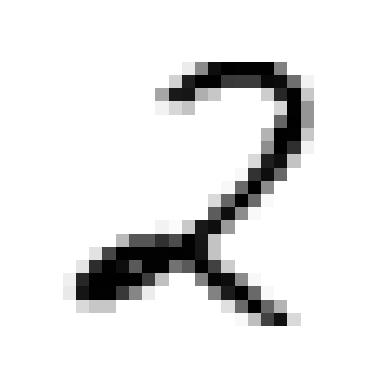

In [7]:
%matplotlib inline
import matplotlib
import matplotlib.pyplot as plt

some_digit = X[36009]
some_digit_image =  some_digit.reshape(28, 28)
plt.imshow(some_digit_image, cmap=matplotlib.cm.binary,
           interpolation="nearest")
plt.axis("off")
plt.show()

# Create Training and Test Sets

In [8]:
# Split into training and test sets
X_train, X_test, y_train, y_test = X[:60000], X[60000:], y[:60000], y[60000:]

In [9]:
# Shuffling the training set
import numpy as np

shuffle_index = np.random.permutation(60000)
X_train, y_train = X_train[shuffle_index], y_train[shuffle_index]

## Training a Binary Classifier

In [12]:
# Create the target vector for the classification task
y_train_2 = (y_train == '2')
y_test_2 = (y_test == '2')

In [13]:
# Choose binary classifier, stochastic gradient descent(SGD)
from sklearn.linear_model import SGDClassifier

sgd_clf = SGDClassifier(random_state=42)
sgd_clf.fit(X_train, y_train_2)

SGDClassifier(random_state=42)

In [14]:
sgd_clf.predict([some_digit])

array([ True])

# Evaluating Model's Performance

## Measuring Accuracy Using Cross-validation

In [15]:
# Using cross validation
from sklearn.model_selection import cross_val_score
cross_val_score(sgd_clf, X_train, y_train_2, cv=3, scoring="accuracy")

array([0.97495, 0.9724 , 0.96075])

In [16]:
# Trying a simple classifier to compare sgd_clf performance
from sklearn.base import BaseEstimator

class Never2Classifier(BaseEstimator):
  def fit(self, X, y=None):
    return self
  def predict(self, X):
    return np.zeros((len(X), 1), dtype=bool)

print((y_train_2 == True).sum()/len(y_train_2))

0.0993


## Confusion Matrix

In [17]:
from sklearn.model_selection import cross_val_predict

y_train_pred = cross_val_predict(sgd_clf, X_train, y_train_2, cv=3)

In [18]:
from sklearn.metrics import confusion_matrix
confusion_matrix(y_train_2, y_train_pred)

array([[52963,  1079],
       [  759,  5199]])

## Precision and Recall

In [20]:
from sklearn.metrics import precision_score, recall_score
precision_score(y_train_2, y_train_pred)

0.8281299776999044

In [21]:
recall_score(y_train_2, y_train_pred)

0.8726082578046325

## F1 Score

In [22]:
from sklearn.metrics import f1_score
f1_score(y_train_2, y_train_pred)

0.8497875122589081

In scikit-learn, it is possible to get the scores from the decision function also through cross_val_predict()

In [23]:
y_scores = cross_val_predict(sgd_clf, X_train, y_train_2, cv=3,
                             method="decision_function")

In [24]:
# Compute for all possible thresholds via precision_recall_curve()
from sklearn.metrics import precision_recall_curve

precisions, recalls, thresholds = precision_recall_curve(y_train_2,
                                                         y_scores)

In [ ]:
# Plot of precision and recall as a function of thresholds using matplotlib

def plot_precision_recall_vs_threshold(precisions, recalls, thresholds):
  plt.plot(thresholds, precisions[:-1], "b-", label="Pre")